Types of Encoding:
1->Binning /Discretizatio
2->Binarization

Types of Discreatization

Binning:
1->unsupervised
                ->Equal Width binning
                ->equal freqency binnig
                ->k means binning
2->supervised
                ->Decision Tree Binning
3->custom binnig

1->Equal Width binning:
        ->uses for outlier handling
        ->here spread of data is uniformed

2->Equal frequency binning:
        ->ex: if intervals=10 then Each interval contains 10 % of obsertvations values
        ->spreads becomes uniform
        ->handling outliers

3-> K-means Binning:

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv("titanic.csv",usecols=['Age','Fare','Survived'])

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.dropna(inplace=True)

In [8]:
df.shape

(714, 3)

In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [16]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [17]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [22]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6275039123630672

In [30]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [31]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [32]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [33]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [34]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [35]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [37]:
output=pd.DataFrame(
    {
        'age':x_train['Age'],
        'age_trf':x_train_trf[:,0],
        'fare':x_train['Fare'],
        'fare_trf':x_train_trf[:,1]
    }
)

In [41]:
output['age_labels']=pd.cut(x=x_train['Age'],
                            bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=x_train['Fare'],
                             bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [42]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
302,19.0,2.0,0.0000,0.0,"(14.0, 19.0]",NaN
6,54.0,9.0,51.8625,8.0,"(50.0, 80.0]","(51.479, 82.171]"
616,34.0,6.0,14.4000,4.0,"(32.0, 36.0]","(13.0, 15.75]"
234,24.0,3.0,10.5000,3.0,"(22.0, 25.0]","(9.225, 13.0]"
569,32.0,6.0,7.8542,1.0,"(28.5, 32.0]","(7.75, 7.896]"


In [49]:
def discretize(bins,strategy):
      kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
      kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
      
      trf=ColumnTransformer(
          [
              ('first',kbin_age,[0]),
              ('second',kbin_fare,[1])
          ]
      )
      
      x_trf=trf.fit_transform(x)
      print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
      
      plt.figure(figsize=(14,4))
      plt.subplot(121)
      plt.hist(x['Age'])
      plt.title('Before')
      
      plt.subplot(122)
      plt.hist(x_trf[:,0],color='red')
      plt.title('after')
      
      plt.show()
      
      plt.figure(figsize=(14,4))
      plt.subplot(121)
      plt.hist(x['Fare'])
      plt.title('Before')
      
      plt.subplot(122)
      plt.hist(x_trf[:,1],color='red')
      plt.title('after')
            

0.6386932707355242


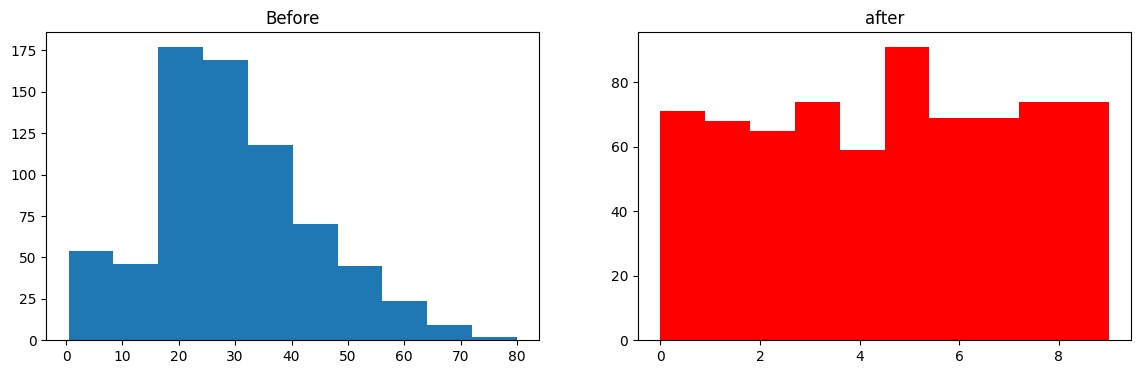

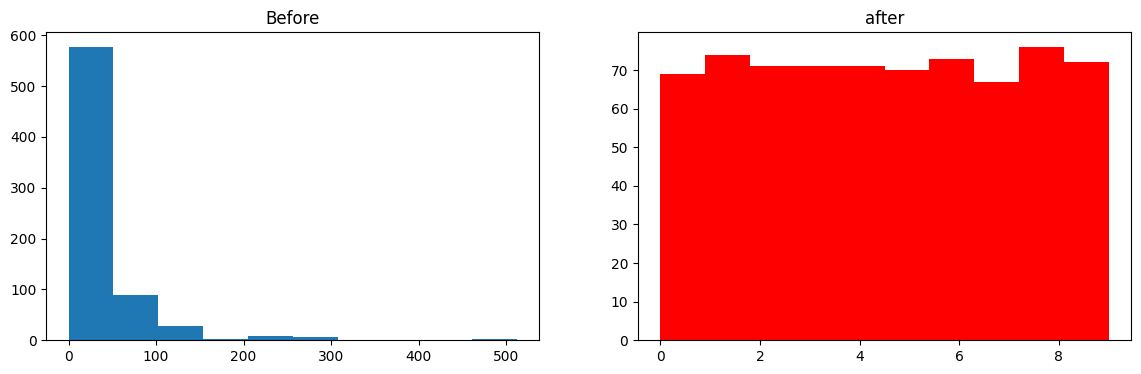

In [50]:
discretize(10,'quantile')

0.6261345852895148


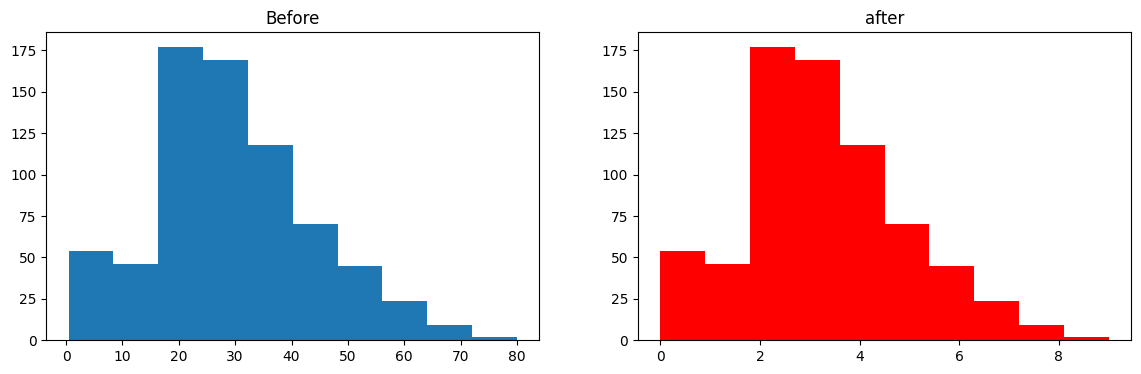

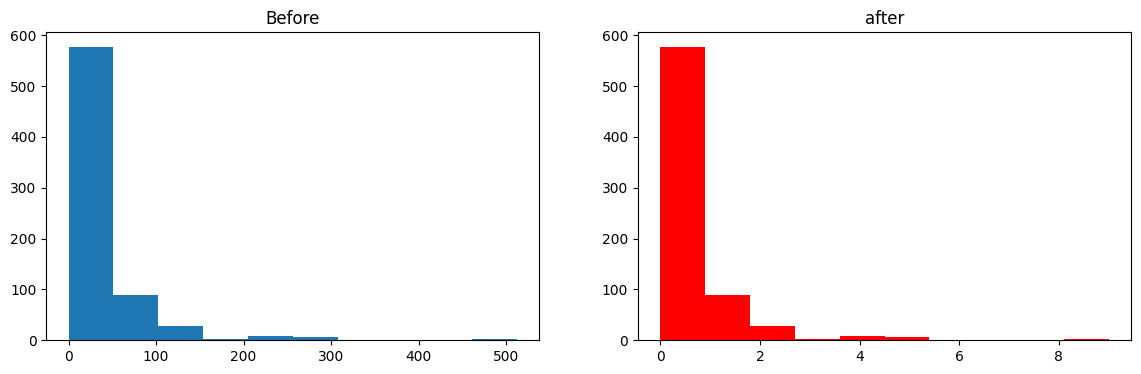

In [51]:
discretize(10,'uniform')

0.6344874804381846


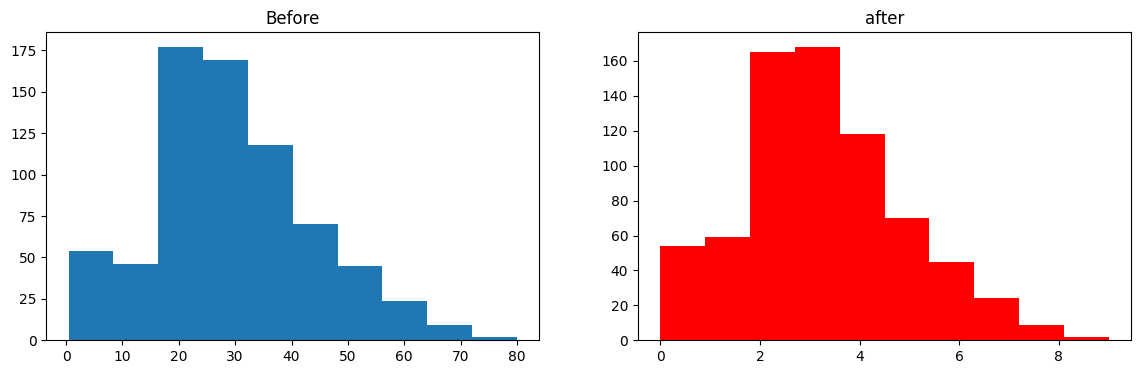

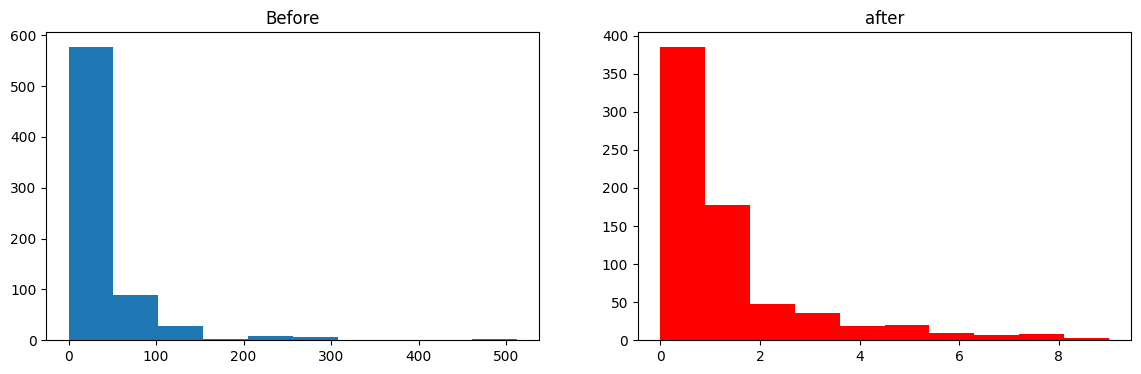

In [52]:
discretize(10,'kmeans')

                      Binarization

In [72]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','SibSp','Parch','Survived'])

In [73]:
df.dropna(inplace=True)

In [74]:
df['family']=df['SibSp']+df['Parch']

In [75]:
df.head()

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [76]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [77]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
x_train.head()

,Age,SibSp,Parch,Fare,family
328,31.0,1,1,20.5250,2
73,26.0,1,0,14.4542,1
253,30.0,1,0,16.1000,1
719,33.0,0,0,7.7750,0
666,25.0,0,0,13.0000,0


In [79]:
#without binarization

clf=DecisionTreeClassifier()

clf.fit(x_train,y_train)

y_pred=clf.predict(x_test)

accuracy_score(y_test,y_pred)

0.6363636363636364

In [85]:
x_train

,Age,SibSp,Parch,Fare,family
328,31.0,1,1,20.5250,2
73,26.0,1,0,14.4542,1
253,30.0,1,0,16.1000,1
719,33.0,0,0,7.7750,0
666,25.0,0,0,13.0000,0
...,...,...,...,...,...
92,46.0,1,0,61.1750,1
134,25.0,0,0,13.0000,0
337,41.0,0,0,134.5000,0
548,33.0,1,1,20.5250,2


In [80]:
#applying Binarization

from sklearn.preprocessing import Binarizer

In [81]:
trf=ColumnTransformer(
    [
        ('bin',Binarizer(copy=False,threshold=0),['family'])
    ],
    remainder='passthrough'
)

In [82]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [86]:
pd.DataFrame(x_train_trf,columns=['family','Age','Fare','SiSp','Parch'])

,family,Age,Fare,SiSp,Parch
0,1.0,31.0,1.0,1.0,20.5250
1,1.0,26.0,1.0,0.0,14.4542
2,1.0,30.0,1.0,0.0,16.1000
3,0.0,33.0,0.0,0.0,7.7750
4,0.0,25.0,0.0,0.0,13.0000
...,...,...,...,...,...
566,1.0,46.0,1.0,0.0,61.1750
567,0.0,25.0,0.0,0.0,13.0000
568,0.0,41.0,0.0,0.0,134.5000
569,1.0,33.0,1.0,1.0,20.5250


In [87]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test_trf)

accuracy_score(y_test,y_pred)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6013986013986014